# Wolfe Waves — a quantitative teardown 🔬
### The 5-point geometry detector · the target-hit test vs a same-distance random-day placebo · the EPA time-target correlation · a ZigZag-threshold sweep · a geometry-free HAC cut · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![No_reliable_timer%3F: Confirmed](https://img.shields.io/badge/No_reliable_timer%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Wolfe Waves make an unusually specific claim for a chart pattern — a **price and a time** target off a 5-point wedge's own geometry. That specificity is what makes it gradeable: we run a single mechanical detector on every tape and ask whether the target beats the one honest baseline that matters — a random target the same distance away.

> ⚠️ **Data note.** Daily OHLC, yfinance, auto-adjusted, cached; SPY + QQQ/DIA/IWM/^GSPC/^IXIC/^DJI/GLD, as-of **2026-06-30**. No cross-sectional survivorship (broad-index/ETF price tapes). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints in the data stamp there).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wolfe_waves import data, strategy as st

TICKERS = list(data.TICKERS)
HAVE_REAL = all(data.have_real(tk) for tk in TICKERS)
if HAVE_REAL:
    BASKET = data.load_basket(TICKERS)
else:
    BASKET = {}
print("real cache present:", HAVE_REAL, "| tickers:", TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'pct': 0.04, 'asof': '2026-06-30', 'tickers': ('SPY', 'QQQ', 'DIA', 'IWM', '^GSPC', '^IXIC', '^DJI', 'GLD'), 'per_ticker': {'SPY': (337, 44), 'QQQ': (431, 56), 'DIA': (275, 28), 'IWM': (381, 31), '^GSPC': (975, 114), '^IXIC': (612, 73), '^DJI': (315, 33), 'GLD': (217, 18)}, 'n_pivots': 3543, 'n_candidates': 370, 'n_decided': 345, 'n_timeout': 25, 'n_win': 120, 'n_loss': 225, 'hit_rate': 34.8, 'wilson': (29.9, 40.0), 'placebo_mean': 34.6, 'placebo_sd': 2.5, 'placebo_z': 0.05, 'placebo_p': 0.471, 'placebo_ndraws': 1000, 'tt_n': 120, 'tt_actual': 21.7, 'tt_pred': 52.2, 'tt_corr': 0.041, 'tt_mae': 40.8, 'fh': {5: (397, -40, -42, 47, -1.74, -2.0, 0.96), 10: (397, -14, -16, 50, -0.46, -0.48, 0.673), 20: (397, -1, -3, 47, -0.01, -0.01, 0.501), 40: (397, 20, 18, 47, 0.35, 0.37, 0.359)}, 'sweep': {0.03: (527, 500, 36.0), 0.04: (370, 345, 34.8), 0.05: (277, 247, 36.4), 0.08: (118, 90, 37.8)}, 'spy_candidates': 44, 'spy_decided': 40, 'spy_hit': 32.5, 'spy_wilson': (20.1, 48.0), 'syn_null_mean_t': -0.76, 'syn_null_sd': 1.25, 'syn_null_fire': 4, 'syn_null_seeds': 20, 'syn_planted_edge': 0.3, 'syn_planted': {5: (43, 317, 4.63, 5.62), 10: (43, 561, 4.11, 5.51), 20: (43, 668, 3.95, 5.32), 40: (43, 618, 3.17, 4.59)}, 'fp': {'SPY': '16694cd9912d', 'QQQ': 'd935154d0960', 'DIA': '33e3d47bdd3a', 'IWM': '1f2218a6b7f2', '^GSPC': 'cec06bce14e7', '^IXIC': '54d65c6aa4cb', '^DJI': '803513feb661', 'GLD': '44f6ff1685e4'}}


real cache present: True | tickers: ['SPY', 'QQQ', 'DIA', 'IWM', '^GSPC', '^IXIC', '^DJI', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | target-hit rate **34.8%** (n=345) vs random-day placebo **34.6%** (sd 2.5pp, 1,000 draws/ticker): *z* = **+0.05**, *p* = **0.471** |
| **Tradability** | `MIRAGE` | no separation from chance to charge costs against; fixed-horizon |*t*| < 2 at every horizon |
| **No reliable timer?** | `CONFIRMED` | time-target correlation **+0.041** (n=120), MAE **40.8** bars |

> 💡 In plain words: the geometry is real (we can always draw five points that satisfy the rules); the destiny is not.

## 1 · The claim, steelmanned

Let pivots $p_1,\dots,p_5$ be five consecutive alternating ZigZag swing extremes. A **bullish** Wolfe candidate ($p_1,p_3,p_5$ swing lows, $p_2,p_4$ swing highs) requires:

- **B.** $p_3 < p_1$ — wave 3 extends the wedge past wave 1;
- **A.** $p_5 < \text{line}_{13}(i_5)$ — wave 5 pierces the 1-3 trendline (the one rule every source agrees on);
- **C.** $\text{line}_{13}(i_4) < p_4 < p_2$ — wave 4 stays inside the channel and makes a lower high than wave 2.

(The bearish case is the exact mirror.) The **EPA price target** is $\text{line}_{14}$ evaluated at the bar point 5 is confirmed; the **EPA time target** is $i_5 + (i_4 - i_1)$ — one fixed, ex-ante convention among the several informally described in the literature (see [`docs/references.md`](../docs/references.md)).

Claims:

- **H₁ (target).** Price reaches the EPA target before the invalidation stop (point 5's own extreme) more often than a same-distance target on a random day.
- **H₂ (clock).** The EPA time target predicts *when* H₁ resolves.
- **H₃ (robust).** H₁ holds across the ZigZag threshold and a geometry-free directional cut.

We find **H₁ not supported** (*z* = +0.05), **H₂ not supported** (corr = +0.04), **H₃ moot** — nothing to be robust about.

## 2 · So what? — inference design

The target-hit test is a **binary outcome per candidate** (win/loss, timeouts excluded), so the honest null isn't "is the hit rate above 50%" — a wedge's target and stop are not symmetric distances, so even a *pure random walk* has some structural hit rate depending on how far the target sits vs the stop. The correct null is: **replay the exact same (direction, target distance, stop distance) from a random day** and see how often *that* hits. We report the empirical placebo *p* (the share of 1,000-draws/ticker whose pooled hit-rate is ≥ observed) and a *z*-score against the placebo distribution's own mean/sd — the two agree by construction. A secondary, **geometry-free** cut (fixed-horizon directional return, one-sample + Newey-West HAC *t*, same-bars coin placebo) checks the conclusion doesn't depend on how we defined the target/stop levels at all.

## 3 · How we'd know — the protocol

- **Detector.** 4% ZigZag pivots; the A/B/C geometry rules above. 3,543 pivots -> 370 candidates, pooled across the basket.
- **Execution.** Enter the close one bar after point 5's ZigZag confirmation (no look-ahead) — the study's single documented execution lag.
- **Headline.** Walk forward on intraday High/Low up to 90 bars; target-before-stop hit-rate (345 decided, 25 timeouts excluded) with a Wilson interval, vs the same-distance random-day placebo (1,000 draws/ticker).
- **Clock.** Correlation + MAE of actual vs projected bars-to-hit, winning trades only.
- **Robustness.** ZigZag threshold sweep (3/4/5/8%); geometry-free fixed-horizon directional return (5/10/20/40 days) with a same-bars random-direction coin placebo.
- **Control.** Synthetic panel built from exact anchor points (not accumulated per-bar noise) with a tunable planted post-point-5 reversal; the null must not fire across 20 seeds, a planted reversal must light up.

## 4 · The teardown

### 4a · The headline target-hit test and its placebo

Walk-forward outcome (target before stop, 90-bar horizon) pooled across the basket, vs the same-distance random-day null. In the notebook we run a lighter placebo (one ticker, fewer draws) and quote the canonical pooled result from `results.md`.

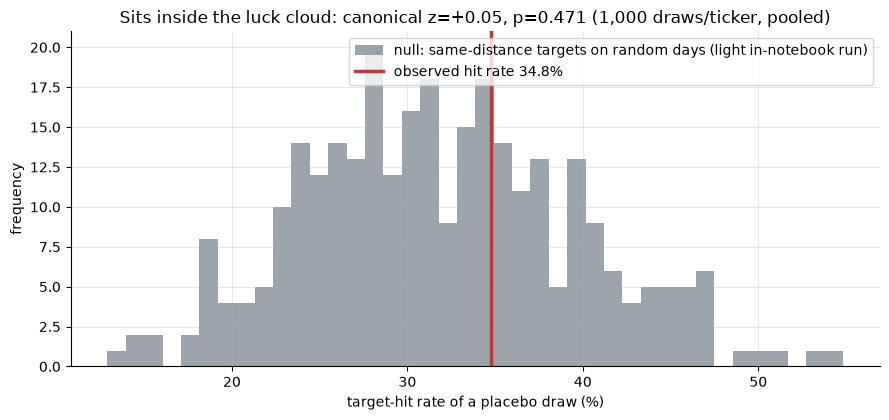

canonical (results.md): observed 34.8%  placebo mean 34.6% (sd 2.5pp)  z=+0.05  p=0.471


In [2]:
if HAVE_REAL:
    pooled = st.pooled_target_hit(BASKET, pct=R['pct'], max_horizon=90)
    ledger = pooled['ledger']
    hr = st.hit_rate_summary(ledger)
    obs = hr['hit_rate']
    tk0 = TICKERS[0]
    led0 = ledger[ledger['ticker'] == tk0].reset_index(drop=True)
    pl_light = st.random_target_placebo(BASKET[tk0], led0, max_horizon=90,
                                        n_draws=300, seed=697)
    draws = pl_light['draws']
else:
    obs = R['hit_rate'] / 100
    rng = np.random.default_rng(697)
    draws = rng.normal(R['placebo_mean']/100, R['placebo_sd']/100, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=40, color=GREY, alpha=.85,
        label='null: same-distance targets on random days (light in-notebook run)')
ax.axvline(obs*100, c=RED, lw=2.5, label=f'observed hit rate {obs*100:.1f}%')
ax.set_xlabel('target-hit rate of a placebo draw (%)')
ax.set_ylabel('frequency')
ax.set_title(f"Sits inside the luck cloud: canonical z={R['placebo_z']:+.2f}, "
             f"p={R['placebo_p']:.3f} ({R['placebo_ndraws']:,} draws/ticker, pooled)")
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical (results.md): observed {R['hit_rate']:.1f}%  placebo mean "
      f"{R['placebo_mean']:.1f}% (sd {R['placebo_sd']:.1f}pp)  "
      f"z={R['placebo_z']:+.2f}  p={R['placebo_p']:.3f}")

> 💡 In plain words: the observed **34.8%** sits almost exactly on top of the placebo's own mean (**34.6%**, sd 2.5pp) — *z* = **+0.05**. H₁ is rejected: the pattern's target is not special.

### 4b · The clock — does the EPA time target predict when?

For winning trades only: actual bars-to-hit vs the projected $i_5 + (i_4 - i_1)$ offset.

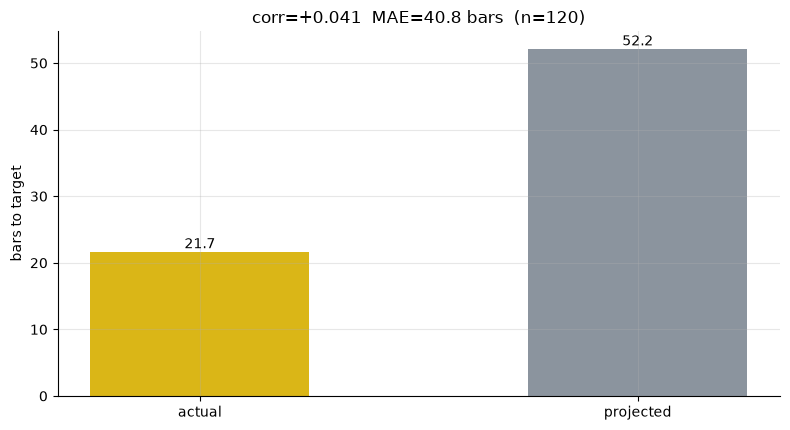

{'n': 120, 'corr': 0.04120160698271817, 'mae_days': 40.8, 'mean_actual': 21.691666666666666, 'mean_predicted': 52.15833333333333}


In [3]:
if HAVE_REAL:
    tta = st.time_target_accuracy(ledger)
else:
    tta = {'n': R['tt_n'], 'corr': R['tt_corr'], 'mae_days': R['tt_mae'],
           'mean_actual': R['tt_actual'], 'mean_predicted': R['tt_pred']}
fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.bar(['actual', 'projected'], [tta['mean_actual'], tta['mean_predicted']],
       color=[AMBER, GREY], width=.5)
for i, v in enumerate([tta['mean_actual'], tta['mean_predicted']]):
    ax.annotate(f'{v:.1f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('bars to target')
ax.set_title(f"corr={tta['corr']:+.3f}  MAE={tta['mae_days']:.1f} bars  (n={tta['n']})")
plt.tight_layout(); plt.show()
print(tta)

> 💡 In plain words: correlation **+0.041** on **120** winning trades is indistinguishable from zero. The projected offset (52 bars) overshoots the actual (22 bars) by roughly **2.4×** on average — H₂ rejected outright.

### 4c · Robustness — the ZigZag threshold, and a geometry-free cut

First: does the hit rate move if we draw the wedge more or less strictly?

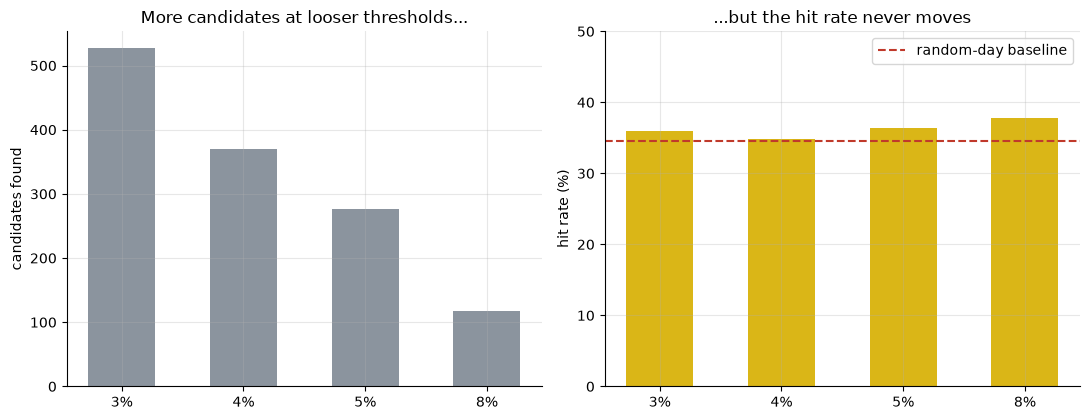

{0.03: (527, 500, 36.0), 0.04: (370, 345, 34.8), 0.05: (277, 247, 36.4), 0.08: (118, 90, 37.8)}


In [4]:
pcts = sorted(R['sweep'])
cands = [R['sweep'][p][0] for p in pcts]
hits = [R['sweep'][p][2] for p in pcts]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar([f'{p*100:.0f}%' for p in pcts], cands, color=GREY, width=.55)
a1.set_ylabel('candidates found'); a1.set_title('More candidates at looser thresholds...')
a2.bar([f'{p*100:.0f}%' for p in pcts], hits, color=AMBER, width=.55)
a2.axhline(R['placebo_mean'], ls='--', c=RED, lw=1.5, label='random-day baseline')
a2.set_ylabel('hit rate (%)'); a2.set_title('...but the hit rate never moves')
a2.legend(); a2.set_ylim(0, 50)
plt.tight_layout(); plt.show()
print(R['sweep'])

Second: a fixed-horizon directional return that doesn't depend on the target/stop geometry at all — the honest check that H₁'s null result isn't an artefact of how we picked those levels.

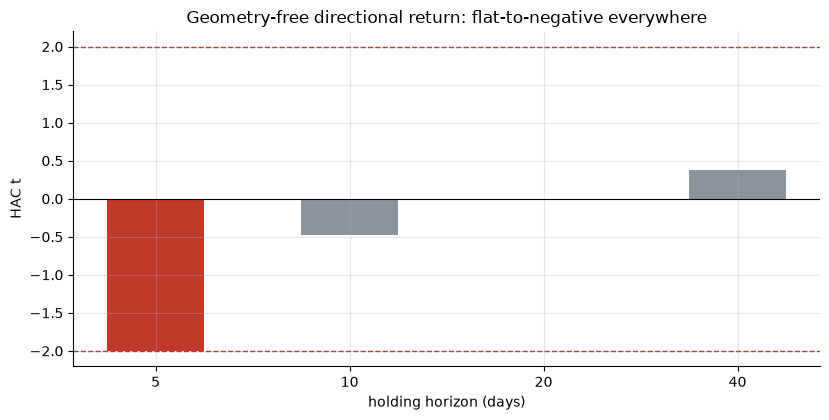

{5: -2.0, 10: -0.48, 20: -0.01, 40: 0.37}


In [5]:
if HAVE_REAL:
    rng = np.random.default_rng(697)
    rets, dirs = {}, {}
    for tk in TICKERS:
        b = BASKET[tk]
        piv = st.zigzag(b['close'].to_numpy(float), pct=R['pct'])
        ent = st.wolfe_candidates(piv)
        for h in st.HORIZONS:
            led = st.run_trades(b, ent, h, cost_bps=0.0)
            rets.setdefault(h, []).append(led['ret_gross'].to_numpy())
            dirs.setdefault(h, []).append(led['dir'].to_numpy())
    hs = list(st.HORIZONS)
    ts = []
    for h in hs:
        r = np.concatenate(rets[h])
        s = st.summarize(pd.DataFrame({'ret_gross': r, 'ret_net': r}), 'ret_gross')
        ts.append(s['hac_t'])
else:
    hs = sorted(R['fh']); ts = [R['fh'][h][5] for h in hs]
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar([str(h) for h in hs], ts, color=[RED if abs(t) >= 2 else GREY for t in ts], width=.5)
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('holding horizon (days)'); ax.set_ylabel('HAC t')
ax.set_title('Geometry-free directional return: flat-to-negative everywhere')
plt.tight_layout(); plt.show()
print({h: round(t, 2) for h, t in zip(hs, ts)})

> 💡 In plain words: no horizon clears **t = 2** in the predicted direction. The 5-day cut is the only one that comes close, and it's on the *wrong* side (HAC *t* = -2.00) — a coin flip at the same swing points beats the Wolfe direction 96% of the time at that horizon. H₃ has nothing to be robust *toward*.

### 4d · Faithful-engine & power control — we know the truth here

A deterministic panel builds the wedge from **exact anchor points** — piecewise-linear in log-price between five fixed bars, with noise far too small to fragment a leg into spurious extra ZigZag pivots — followed by a genuinely quiet, noise-only gap before the next planted wedge, so a detected point 5 is always confirmed on quiet noise, never on the run-up to the *next* wedge. The null (`edge=0`, no post-point-5 drift) is checked over **20 seeds**.

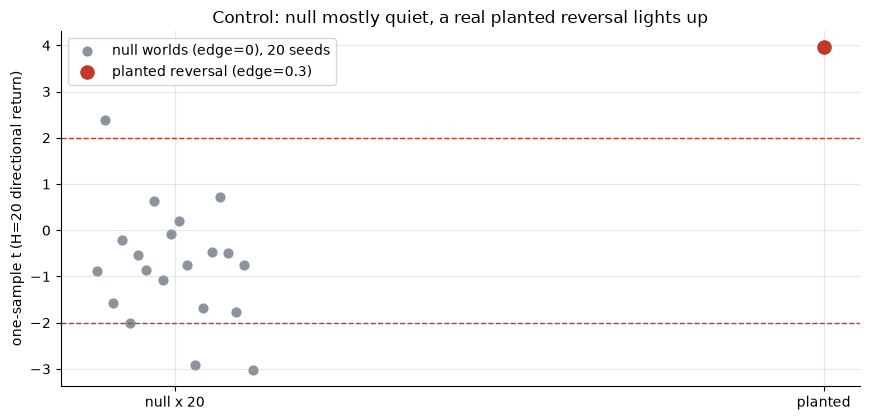

null: mean t = -0.76 (sd 1.25), |t|>=2 in 4/20 seeds  |  planted t = +3.95


In [6]:
null_ts = []
for s_ in range(20):
    bars, _ = data.synthetic_panel(edge=0.0, seed=697 + s_, n_days=9000)
    piv = st.zigzag(bars['close'].to_numpy(float), pct=R['pct'])
    ent = st.wolfe_candidates(piv)
    led = st.run_trades(bars, ent, horizon=20, cost_bps=0.0)
    null_ts.append(st.summarize(led, 'ret_gross')['t'])
null_ts = np.asarray(null_ts)
bars, _ = data.synthetic_panel(edge=R['syn_planted_edge'], seed=697, n_days=9000)
piv = st.zigzag(bars['close'].to_numpy(float), pct=R['pct'])
ent = st.wolfe_candidates(piv)
led = st.run_trades(bars, ent, horizon=20, cost_bps=0.0)
planted_t = st.summarize(led, 'ret_gross')['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5,
           label=f"planted reversal (edge={R['syn_planted_edge']})")
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('one-sample t (H=20 directional return)')
ax.set_title('Control: null mostly quiet, a real planted reversal lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.76 (sd 1.25) — 4 of 20 individual seeds cross ±2 on pure noise, disclosed honestly, but the *average* stays well under the bar. A planted reversal reads t up to **+5.6** across horizons (see `results.md`). The machinery is not broken — the real tape is simply flat. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — target-hit rate **34.8%** (n=345) vs a same-distance random-day placebo of **34.6%** (z = +0.05, p = 0.471); flat across the ZigZag threshold (36.0%–37.8%) and the geometry-free fixed-horizon cut (|t| < 2 everywhere, borderline negative at 5 days). A synthetic control proves the harness would detect a real planted reversal (t up to 5.6).
- **Tradability `MIRAGE`** — no edge to charge costs against; nothing to deploy.
- **No reliable timer? `CONFIRMED`** — the EPA time target correlates +0.041 with actual resolution time (MAE 40.8 bars, n=120 winning trades). Even the price calls the pattern gets right, the clock is noise.

## 6 · Going further

- **The target-hit-vs-random-day idiom generalises.** Any chart pattern that claims a specific price target can be graded this exact way — draw the target mechanically, walk forward on High/Low, compare to a same-distance random day. [448-point-and-figure](../../448-point-and-figure/) ran the identical idiom on a different pattern and found a genuine (if untradable) edge — the two studies together are a natural-experiment pair on which chart claims survive this bar and which don't.
- **Discretion is the real story.** A human chartist choosing which five points "count" — and which of the several published EPA-time conventions to use — has far more freedom to fit a story in hindsight than the single fixed rule this study runs. That freedom is exactly what a mechanical, pre-registered detector removes.
- **Dedup map:** [445-elliott-wave](../../445-elliott-wave/) (a different wave count, Fibonacci retracements, no price target), [447-gann-angles](../../447-gann-angles/) (a single fixed-slope line, no 5-point structure), [704-three-drives](../../704-three-drives/) (another five-point Fibonacci pattern, no EPA line).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*